In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16
})

C:\Users\figne\AppData\Local\Temp\ipykernel_34928\2921239293.py:65: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k:" (-> color='k'). The keyword argument will take precedence.
  plt.plot(w_solid, [1]*len(w_solid), 'k:', color = 'red', alpha = 0.7)
C:\Users\figne\AppData\Local\Temp\ipykernel_34928\2921239293.py:66: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(w_dashed, [1]*len(w_dashed), 'k-', label=r"Trivial $V^*$", color = 'red', alpha = 0.7)


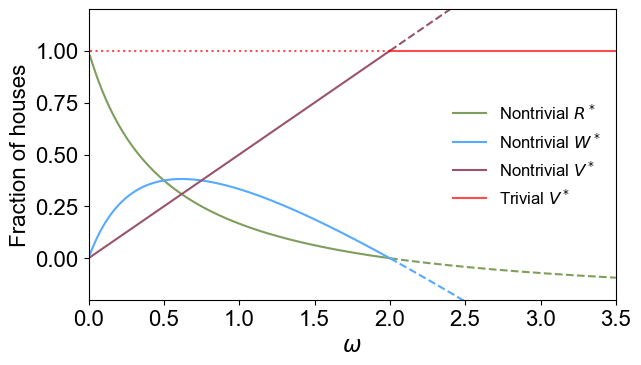

In [8]:
# Fixed parameters
k2 = 20
v_w = 1.0
gamma = 0.2
sigma = 1.0
kappa = 0.5
k1 = 4.0  
H = 100.0

# Compute critical w (whishful rate)
w_critical = gamma*k2 * (1 + kappa/v_w) - sigma*k1

# Define w range
w_all = np.linspace(0.01, w_critical + 1.5, 1000)


R_frac_solid, W_frac_solid, V_frac_solid = [], [], []
R_frac_dashed, W_frac_dashed, V_frac_dashed = [], [], []
w_solid, w_dashed = [], []

for w in w_all:  
    num_R = (gamma*k2*(v_w+kappa) - v_w*(sigma*k1 + w)) * H
    denom_R = gamma*k2*(v_w + kappa + w) - sigma*k1*v_w
    num_V = v_w*w*H
    denom_V = gamma*k2 * (v_w+kappa) - sigma*k1*v_w

    
    if denom_R != 0 and denom_V != 0:
        R = num_R / denom_R
        V = num_V / denom_V
        W = H - R - V
        Rf, Wf, Vf = R/H, W/H, V/H
    else:
        Rf, Wf, Vf = np.nan, np.nan, np.nan

    if w < w_critical:
        w_solid.append(w)
        R_frac_solid.append(Rf)
        W_frac_solid.append(Wf)
        V_frac_solid.append(Vf)
    else:
        w_dashed.append(w)
        R_frac_dashed.append(Rf)
        W_frac_dashed.append(Wf)
        V_frac_dashed.append(Vf)



# Plot
height_in = 100    / 25.4
width_in  = 170/ 25.4

plt.figure(figsize=(width_in, height_in))

# Nontrivial (solid before threshold, dashed after)
plt.plot(w_solid, R_frac_solid, label=r"Nontrivial $R^*$", color='#7f9e5d')
plt.plot(w_solid, W_frac_solid, label=r"Nontrivial $W^*$", color='#56aaff')
plt.plot(w_solid, V_frac_solid, label=r"Nontrivial $V^*$", color='#9b536d')

plt.plot(w_dashed, R_frac_dashed, linestyle='--', color='#7f9e5d')
plt.plot(w_dashed, W_frac_dashed, linestyle='--', color='#56aaff')
plt.plot(w_dashed, V_frac_dashed, linestyle='--', color='#9b536d')

# Trivial (dashed before threshold, solid after)
plt.plot(w_solid, [1]*len(w_solid), 'k:', color = 'red', alpha = 0.7)
plt.plot(w_dashed, [1]*len(w_dashed), 'k-', label=r"Trivial $V^*$", color = 'red', alpha = 0.7)

# Threshold marker
#plt.axvline(x=w_critical, color='red', linestyle='--', label=r'Threshold $\omega$')

plt.xlabel(r"$\omega$", fontsize=16)
plt.ylabel("Fraction of houses", fontsize=16)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.grid(False)
plt.ylim(-0.2, 1.2)
#plt.xlim(min(w_all), max(w_all))
plt.xlim(0, max(w_all))
plt.tight_layout()
#plt.savefig("C:/Users/figne/OneDrive - nyu.edu/CLIMA/Figures/SI_transcritical_bifurcation.pdf", format='pdf', bbox_inches='tight')
plt.show()
